In [1]:
# =================================================
# 1. IMPORTS & SETUP
# =================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import warnings

# Setup
sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams['svg.fonttype'] = 'none'
warnings.simplefilter(action='ignore', category=FutureWarning)

# =================================================
# 2. CONFIGURATION
# =================================================
# This points to the "Optimised Spatial Run" data
WEIGHTED_DIR = r"C:\Users\kaiso\PycharmProjects\BPAI\clustering_results\Results_Weighted\s42_Weighted_Baseline\s42_w_ADI_STATERNK2.0"
GEO_SUMMARY_FILENAME = "+REG+SEN+ERR.csv"
GEO_FULL_DATA_FILENAME = "+REG+SEN+ERR_full_data.csv"
CENSUS_SHAPEFILE_PATH = r"C:\Users\kaiso\PycharmProjects\BPAI\Data\shapefile_2015_BlockGroup_Calif\tl_2015_06_bg.shp"

geo_summary_path = os.path.join(WEIGHTED_DIR, GEO_SUMMARY_FILENAME)
geo_full_data_path = os.path.join(WEIGHTED_DIR, GEO_FULL_DATA_FILENAME)

# =================================================
# 3. DATA LOADING & PREPARATION
# =================================================

# --- Load LA County border for context ---
try:
    census_gdf = gpd.read_file(CENSUS_SHAPEFILE_PATH)
    la_census_gdf = census_gdf[census_gdf['COUNTYFP'] == '037']
    la_border = la_census_gdf.dissolve().to_crs(epsg=3857)
    print("✅ LA County border loaded.")
except Exception as e:
    print(f"❌ Could not load shapefile: {e}")
    la_border = None

# --- Load full geographic data for plotting ---
if os.path.exists(geo_full_data_path):
    df_full = pd.read_csv(geo_full_data_path)
    # --- FIX: Remove division by 1e6 as coordinates are already in decimal format ---
    gdf = gpd.GeoDataFrame(
        df_full,
        geometry=gpd.points_from_xy(df_full.longitude, df_full.latitude),
        crs="EPSG:4326"  # Initial CRS is WGS84
    ).to_crs(epsg=3857) # Reproject to match basemaps
    print(f"✅ Full geographic data loaded with {len(df_full)} properties.")
    # Verify cluster count
    n_clusters = gdf['clusters'].nunique()
    print(f"Found {n_clusters} distinct clusters in the data.")
else:
    gdf = None
    print(f"❌ CRITICAL: Full data not found at {geo_full_data_path}")

# --- Load summary data to identify critical clusters ---
def get_weighted_adi(row):
    if 'ADI_STATERNK_avg' in row.index and not pd.isna(row['ADI_STATERNK_avg']):
        return float(row['ADI_STATERNK_avg'])
    adi_cols = [c for c in row.index if 'ADI_STATERNK' in c and c.endswith('_prop')]
    props = row[adi_cols]
    if props.isna().all() or props.sum() == 0: return np.nan
    weighted_sum = 0; total_prop = 0
    for col in adi_cols:
        try:
            rank = int(col.split('=')[1].replace('_prop', ''))
            prop = float(row[col])
            if not np.isnan(prop):
                weighted_sum += rank * prop
                total_prop += prop
        except: pass
    if total_prop == 0: return np.nan
    return weighted_sum / total_prop

if os.path.exists(geo_summary_path):
    df_summary = pd.read_csv(geo_summary_path)
    df_summary = df_summary[~df_summary['c'].astype(str).str.startswith(('OVERALL', 'SEP'))].copy()
    for col in ['c', 'count', 'logerror_mean', 'abs_logerror_mean', 'diff_vs_rest']:
        df_summary[col] = pd.to_numeric(df_summary[col], errors='coerce')
    df_summary['dominant_adi'] = df_summary.apply(get_weighted_adi, axis=1)
    df_geo_sorted = df_summary.sort_values(by='logerror_mean', ascending=False).dropna(subset=['dominant_adi'])

    # Identify the most critical clusters (top 3 over/under-valued)
    NUM_CLUSTERS_TO_SHOW = 3
    top_overvalued = df_geo_sorted[df_geo_sorted['logerror_mean'] > 0].head(NUM_CLUSTERS_TO_SHOW)
    top_undervalued = df_geo_sorted[df_geo_sorted['logerror_mean'] < 0].sort_values(by='logerror_mean', ascending=True).head(NUM_CLUSTERS_TO_SHOW)

    overvalued_cids = top_overvalued['c'].tolist()
    undervalued_cids = top_undervalued['c'].tolist()
    print(f"✅ Identified critical clusters: {len(overvalued_cids)} overvalued, {len(undervalued_cids)} undervalued.")
else:
    df_geo_sorted = None
    overvalued_cids = []
    undervalued_cids = []
    print(f"❌ CRITICAL: Summary data not found at {geo_summary_path}")


✅ LA County border loaded.
✅ Full geographic data loaded with 38878 properties.
Found 28 distinct clusters in the data.
✅ Identified critical clusters: 3 overvalued, 2 undervalued.


✅ Set plot bounds to: (-13236804.73, 3940526.32, -13096976.87, 4138905.66)


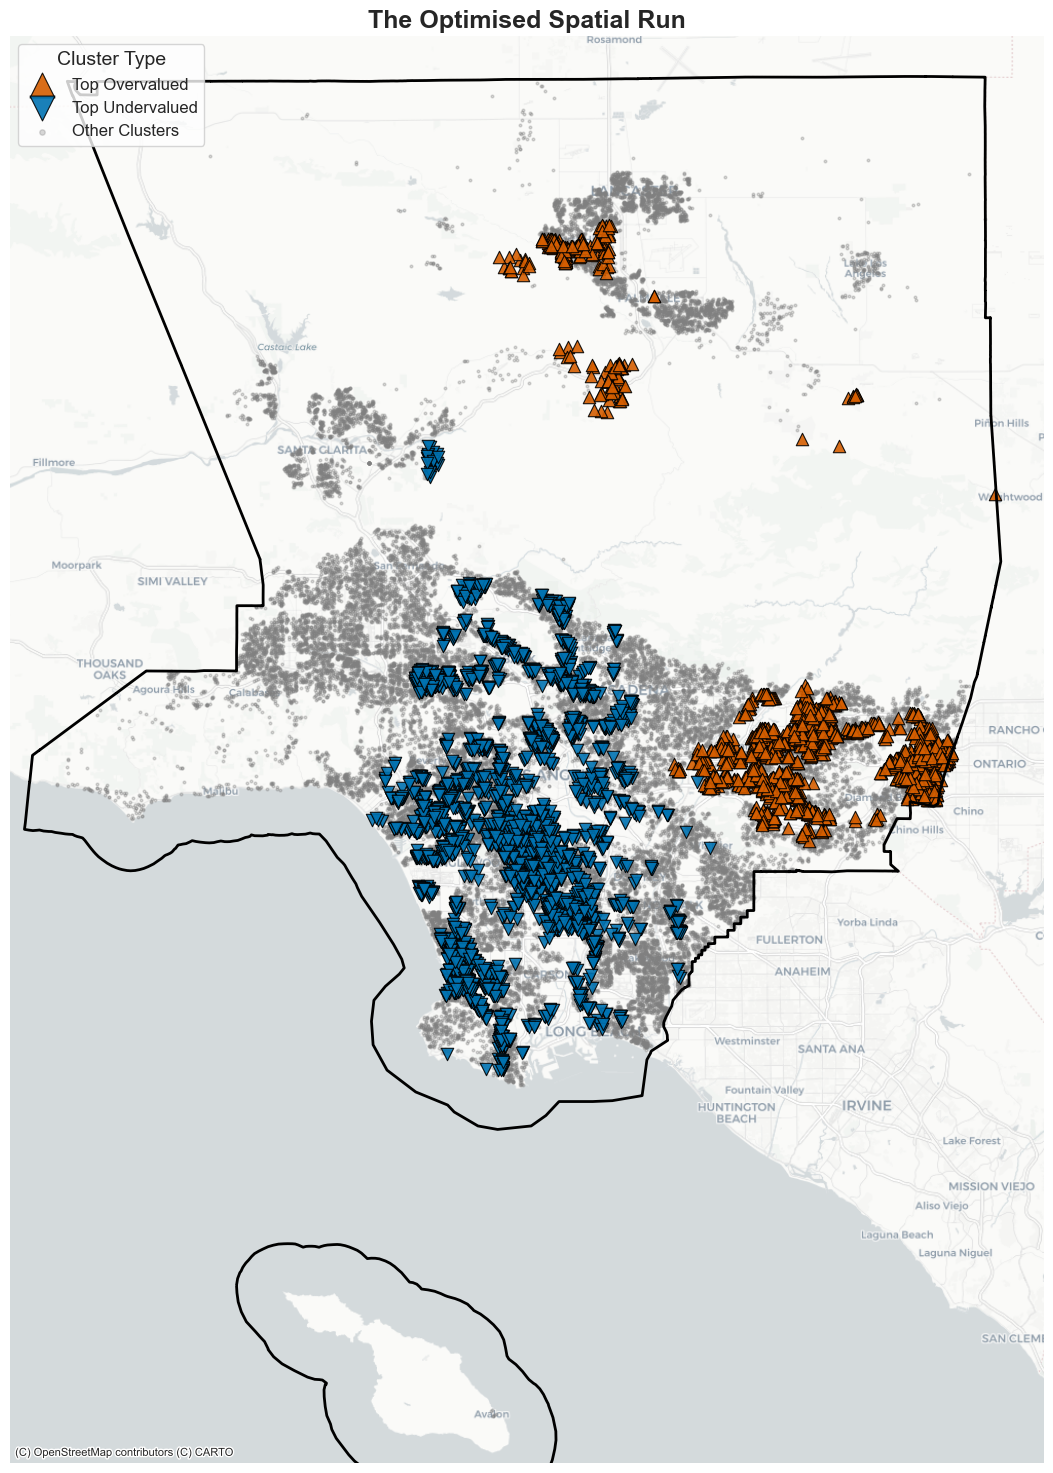

In [2]:
# =================================================
# 4. PLOT FOR COLORBLIND ACCESSIBILITY
# =================================================
if gdf is not None and not gdf.empty:
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    # --- Assign styles for accessibility ---
    cb_palette = sns.color_palette("colorblind")

    # 1. Plot all non-critical clusters in a neutral gray
    gdf_other = gdf[~gdf['clusters'].isin(overvalued_cids + undervalued_cids)]
    gdf_other.plot(ax=ax, color='grey', marker='.', markersize=15, alpha=0.3, label='Other Clusters')

    # 2. Plot overvalued clusters
    gdf_over = gdf[gdf['clusters'].isin(overvalued_cids)]
    if not gdf_over.empty:
        gdf_over.plot(ax=ax, color=cb_palette[3], marker='^', markersize=80, alpha=0.9, edgecolor='black', linewidth=0.8, label='Top Overvalued')

    # 3. Plot undervalued clusters
    gdf_under = gdf[gdf['clusters'].isin(undervalued_cids)]
    if not gdf_under.empty:
        gdf_under.plot(ax=ax, color=cb_palette[0], marker='v', markersize=80, alpha=0.9, edgecolor='black', linewidth=0.8, label='Top Undervalued')

    # --- Final Touches ---
    # Plot LA border
    if la_border is not None:
        la_border.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

    # --- FIX: Set explicit axis limits to prevent a blank plot ---
    # Calculate the total bounds of the primary data and add a small buffer
    try:
        minx, miny, maxx, maxy = gdf.total_bounds
        buffer = (maxx - minx) * 0.05 # 5% buffer
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
        print(f"✅ Set plot bounds to: ({minx:.2f}, {miny:.2f}, {maxx:.2f}, {maxy:.2f})")
    except Exception as e:
        print(f"❌ Could not set plot bounds: {e}")


    # Add basemap for context
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=10)

    ax.set_title('The Optimised Spatial Run', fontsize=18, fontweight='bold')
    ax.axis('off')

    # Create a clear legend
    handles, labels = ax.get_legend_handles_labels()
    try:
        order = [labels.index('Top Overvalued'), labels.index('Top Undervalued'), labels.index('Other Clusters')]
        ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
                  title="Cluster Type", markerscale=2, fontsize=12, title_fontsize=14, loc='upper left')
    except ValueError:
        ax.legend(title="Cluster Type", markerscale=2, fontsize=12, title_fontsize=14, loc='upper left')

    plt.tight_layout()
    plt.savefig('optimised_spatial_run_accessible.pdf', format='pdf', bbox_inches='tight')
    plt.show()

else:
    print("Could not generate plot because data was not loaded.")